In [4]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import kagglehub


# Step 1: Path Setup

path = kagglehub.dataset_download("ankit1743/skyview-an-aerial-landscape-dataset")
dataset_path = os.path.join(path, "Aerial_Landscapes")

Using Colab cache for faster access to the 'skyview-an-aerial-landscape-dataset' dataset.


In [5]:
# Step 2: Image Size & Normalization
# EfficientNet expects 224×224 + ImageNet normalization


IMG_SIZE = 224  # you can also use 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [6]:
# Step 3: Data Augmentation (Train Only)
# These augmentations are ideal for aerial landscapes


train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Random horizontal & vertical flips help aerial images a LOT
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small rotations help because orientation does not matter much
    transforms.RandomRotation(20),

    # Very useful for satellite textures
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),

    # Convert to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet values
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [7]:
# Step 4: Validation / Test Transform
# Only resizing + normalization (NO augmentation)


test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [8]:
# Step 5: Create Train-Validation Split

train_dataset = datasets.ImageFolder(dataset_path, transform=train_transforms)
test_dataset  = datasets.ImageFolder(dataset_path, transform=test_transforms)

# Split 80-20
train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size

train_ds, val_ds = torch.utils.data.random_split(train_dataset, [train_size, val_size])


In [9]:
# Step 6: DataLoaders

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Data pipeline created successfully!")
print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_dataset)}")


Data pipeline created successfully!
Train samples: 9600
Validation samples: 2400
Test samples: 12000


Showing sample augmented images:


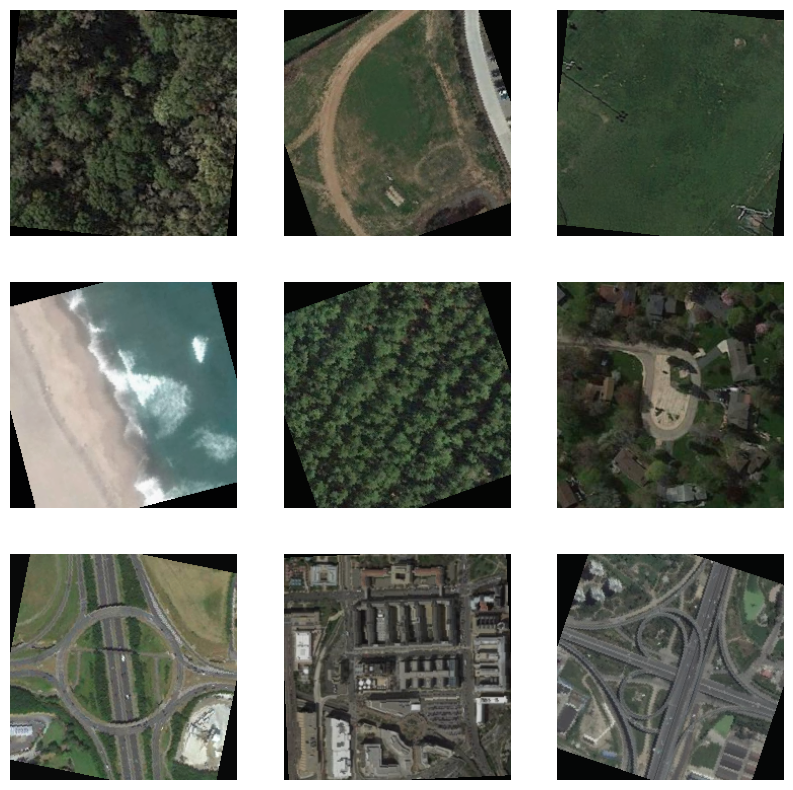

In [10]:
# Step 7: Visualize Augmented Images

def show_batch(dl):
    images, labels = next(iter(dl))
    images = images[:9]  # show first 9

    plt.figure(figsize=(10, 10))
    for i in range(9):
        img = images[i].permute(1, 2, 0).numpy()
        img = IMAGENET_STD * img + IMAGENET_MEAN  # unnormalize

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

print("Showing sample augmented images:")
show_batch(train_loader)
